In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import lineStyles
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

predictions = pd.read_csv("../data/results/predictions.csv")

Y_test = predictions["Actual"]

y_pred_lr = predictions["Linear Regression"]
y_pred_svr = predictions["SVR"]
y_pred_rf = predictions["Random Forest"]
y_pred_xgb = predictions["XGBoost"]


## RMSE / MAE / R²/ Residual Standard Deviation / DataFrame

In [13]:
cv_std = pd.read_csv("../data/results/cv_std.csv")

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(Y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(Y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(Y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(Y_test, y_pred_xgb))
    ],

    "MAE": [
        mean_absolute_error(Y_test, y_pred_lr),
        mean_absolute_error(Y_test, y_pred_svr),
        mean_absolute_error(Y_test, y_pred_rf),
        mean_absolute_error(Y_test, y_pred_xgb)
    ],

    "R²": [
        r2_score(Y_test, y_pred_lr),
        r2_score(Y_test, y_pred_svr),
        r2_score(Y_test, y_pred_rf),
        r2_score(Y_test, y_pred_xgb)
    ],

    "Residual Std": [
        (Y_test - y_pred_lr).std(),
        (Y_test - y_pred_svr).std(),
        (Y_test - y_pred_rf).std(),
        (Y_test - y_pred_xgb).std()
    ]
})

results_df = results_df.merge(
    cv_std,
    on="Model"
)

results_df.to_csv("../data/results/evaluation_results.csv", index=False)

## plot predicted vs actual

In [14]:
def plot_predicted_vs_actual(y_test, y_pred, model_name):

    plt.figure(figsize=(8, 6))

    plt.scatter(y_test, y_pred, alpha=0.6)

    # Perfect prediction line: y = x
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title(f"{model_name} — Predicted vs Actual")

    plt.show()

## run the function

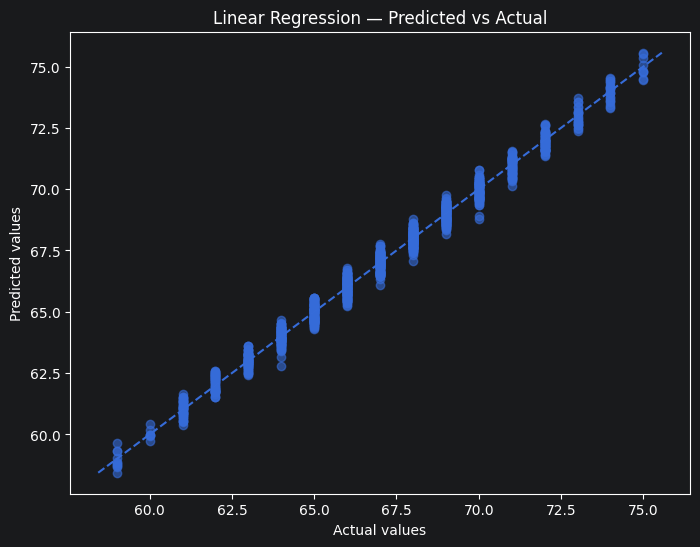

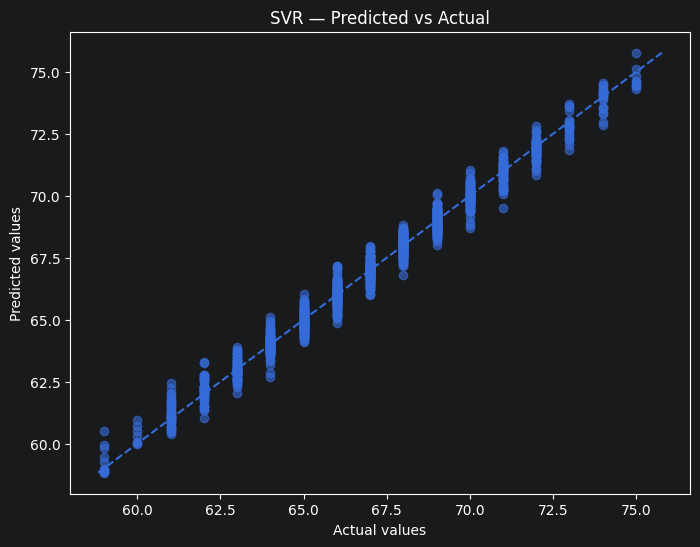

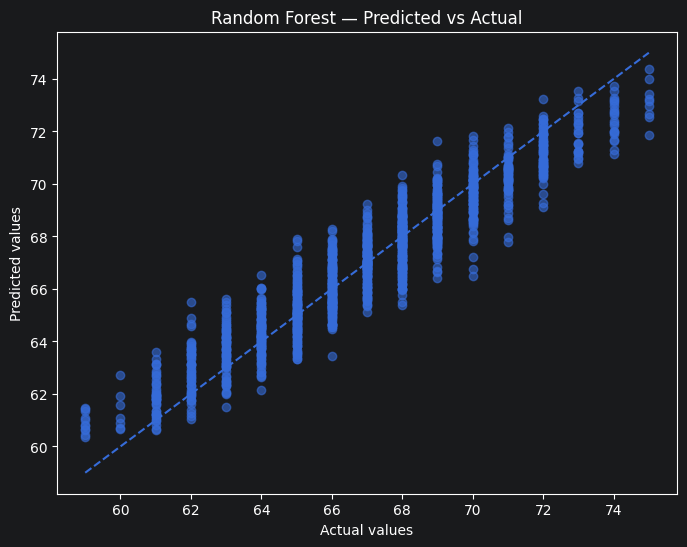

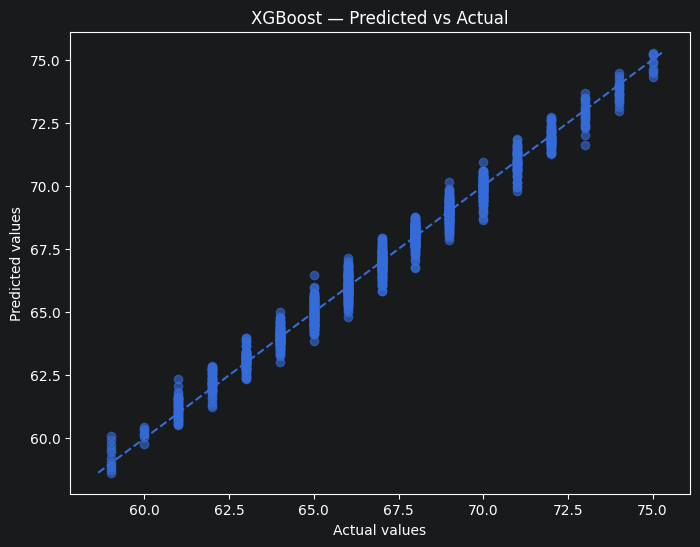

In [15]:
plot_predicted_vs_actual(Y_test, y_pred_lr, "Linear Regression")
plot_predicted_vs_actual(Y_test, y_pred_svr, "SVR")
plot_predicted_vs_actual(Y_test, y_pred_rf, "Random Forest")
plot_predicted_vs_actual(Y_test, y_pred_xgb, "XGBoost")

## residual distribution plots

In [16]:
residual_lr = Y_test - y_pred_lr
residual_svr = Y_test - y_pred_svr
residual_rf = Y_test - y_pred_rf
residual_xgb = Y_test - y_pred_xgb

## Plot the 4 distributions

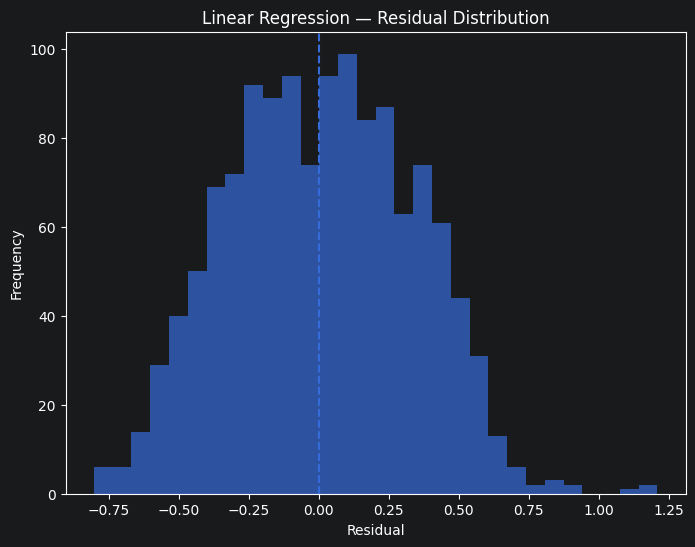

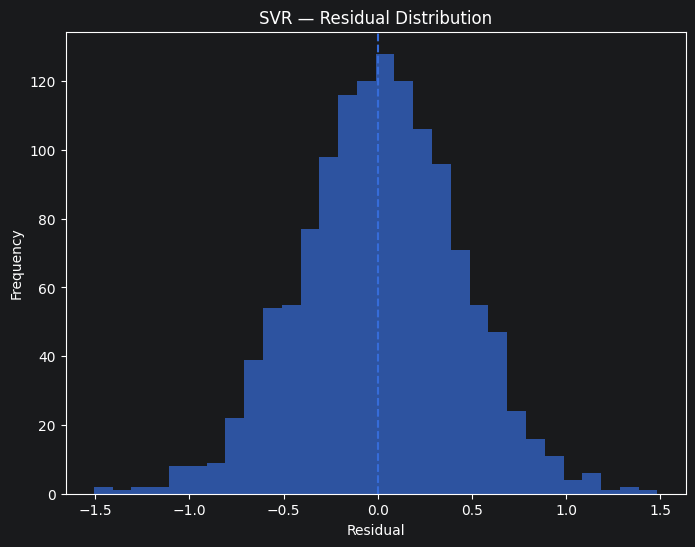

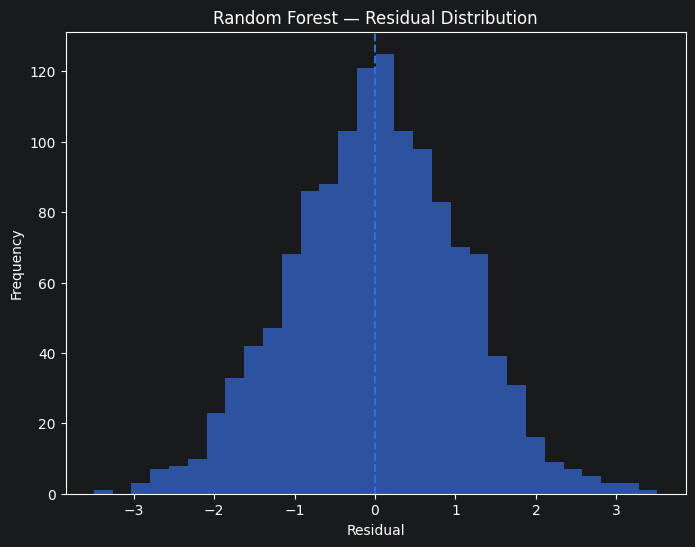

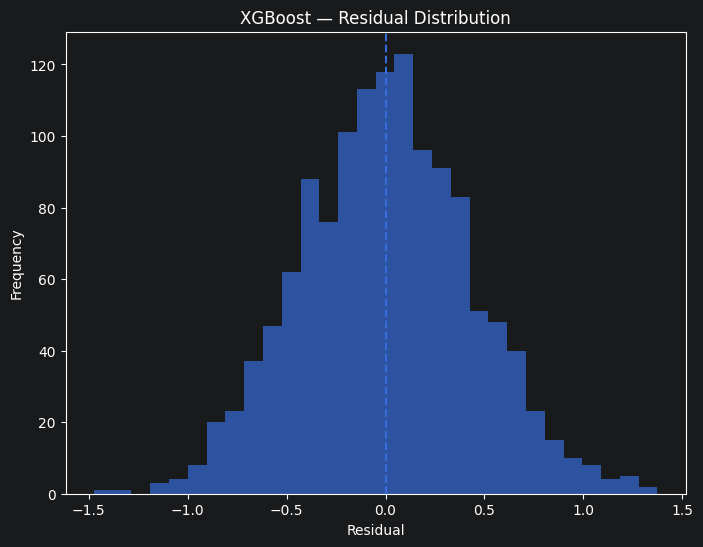

,Model,RMSE,MAE,R²,Residual Std,CV R² Mean,CV R² Std
0,Linear Regression,0.327105,0.271696,0.989720,0.327124,0.989805,0.000493
1,SVR,0.424587,0.336239,0.982679,0.424527,0.981401,0.000864
2,Random Forest,1.056979,0.839794,0.892659,1.057247,0.882362,0.003029
3,XGBoost,0.431068,0.342537,0.982146,0.431206,0.979195,0.000511


In [17]:
residuals = {
    "Linear Regression": residual_lr,
    "SVR": residual_svr,
    "Random Forest": residual_rf,
    "XGBoost": residual_xgb
}

for name, residual in residuals.items():
    plt.figure(figsize=(8, 6))
    plt.hist(residual, bins=30, alpha=0.7)
    plt.axvline(0, linestyle="--")

    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"{name} — Residual Distribution")

    plt.show()

results_df




* R² → higher is better → Linear Regression
* MAE → lower is better → Linear Regression
* RMSE → lower is better → Linear Regression